# Transfer Attack (Black-Box)

## 1. Setup e Import

In [5]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path('..')
BATCH_SIZE = 32
IMG_SIZE = 224
N_CLASSES = 5

NORMALIZE = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

TRAIN_TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor()
])

dataset_path = ROOT / "data" / "fruits-classification-stratified"

train_dataset = ImageFolder(root=dataset_path / 'train', transform=TRAIN_TRANSFORMS)
val_dataset   = ImageFolder(root=dataset_path / 'valid', transform=TRANSFORMS)
test_dataset  = ImageFolder(root=dataset_path / 'test',  transform=TRANSFORMS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

class_names = test_dataset.classes

results_path = ROOT / "results"
results_path.mkdir(exist_ok=True)

print("Setup completato")

Setup completato


## 2. Caricamento modelli
- Modello sorgente: ResNet18
- Modello target: MobileNetV2

In [6]:
source_model = models.resnet18(pretrained=True)

source_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)

source_model = source_model.to(device)

source_model.load_state_dict(torch.load(ROOT / "models" / "best_resnet18.pt", map_location=device))

source_model.eval()

weights = models.MobileNet_V2_Weights.IMAGENET1K_V1

target_model = models.mobilenet_v2(weights=weights)

in_features = target_model.classifier[1].in_features

target_model.classifier[1] = nn.Linear(in_features=in_features, out_features=N_CLASSES)

target_model = target_model.to(device)

target_model_path = ROOT / "models" / "best_mobilenet_v2.pt"

target_model.load_state_dict(torch.load(target_model_path, map_location=device))

target_model.eval()

print("Modelli caricati")
print("Source model: ResNet18")
print("Target model: MobileNetV2")

/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Modelli caricati
Source model: ResNet18
Target model: MobileNetV2


## 3. Valutazione clean — ResNet18 vs MobileNetV2

Verifica la clean accuracy di entrambi i modelli sul test set prima degli attacchi

Nota: Transfer ASR usa solo le immagini classificate correttamente da entrambi i modelli

In [7]:
source_clean_correct_count = 0
target_clean_correct_count = 0
both_correct_count = 0
total_samples = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Valutazione clean"):
        images = images.to(device)
        labels = labels.to(device)

        # predizioni ResNet18
        source_outputs = source_model(NORMALIZE(images))

        source_preds = torch.argmax(source_outputs, dim=1)

        # predizioni MobileNetV2
        target_outputs = target_model(NORMALIZE(images))

        target_preds = torch.argmax(target_outputs, dim=1)

        source_correct = (source_preds == labels)

        target_correct = (target_preds == labels)

        # da usare dopo
        both_correct = (source_correct & target_correct)

        source_clean_correct_count += (source_correct.sum().item())

        target_clean_correct_count += (target_correct.sum().item())

        both_correct_count += (both_correct.sum().item())

        total_samples += labels.size(0)


source_clean_accuracy = (source_clean_correct_count / total_samples)

target_clean_accuracy = (target_clean_correct_count / total_samples)

both_correct_percentage = (both_correct_count / total_samples)

print(f"ResNet18 Accuracy: {source_clean_accuracy:.4f} ({source_clean_accuracy*100:.2f}%)")

print(f"MobileNetV2 Accuracy: {target_clean_accuracy:.4f} ({target_clean_accuracy*100:.2f}%)")

print(f"Immagini corrette da entrambi: {both_correct_count}/{total_samples} ({both_correct_percentage*100:.2f}%)")

Valutazione clean: 100%|██████████| 32/32 [00:00<00:00, 40.06it/s]

ResNet18 Accuracy: 0.9118 (91.18%)
MobileNetV2 Accuracy: 0.9309 (93.09%)
Immagini corrette da entrambi: 881/998 (88.28%)


## 4. Funzioni di attacco

In [8]:
def fgsm_attack(model, images, labels, epsilon, loss_fn):
    """
    Esegue un attacco FGSM su un batch di immagini
    (copia identica da 02_fgsm_attacks.ipynb)
    """
    images.requires_grad = True

    outputs = model(NORMALIZE(images))
    loss = loss_fn(outputs, labels)

    model.zero_grad()
    loss.backward()

    gradient_sign = images.grad.sign()
    perturbation  = epsilon * gradient_sign
    adv_images    = images + perturbation
    adv_images    = torch.clamp(adv_images, 0, 1).detach()
    images.requires_grad = False

    perturbation = adv_images - images

    return adv_images, perturbation.detach()


def pgd_attack(model, images, labels, epsilon, alpha, num_steps, loss_fn):
    """
    Esegue un attacco PGD su un batch di immagini
    (copia identica da 03_pgd_attacks.ipynb)
    """
    adv_images = images.clone().detach()
    adv_images = adv_images + torch.empty_like(adv_images).uniform_(-epsilon, epsilon)
    adv_images = torch.clamp(adv_images, 0, 1).detach()

    for _ in range(num_steps):
        adv_images.requires_grad = True
        outputs = model(NORMALIZE(adv_images))
        loss    = loss_fn(outputs, labels)
        model.zero_grad()
        loss.backward()

        gradient_sign = adv_images.grad.sign()
        adv_images    = adv_images.detach() + alpha * gradient_sign
        perturbation  = torch.clamp(adv_images - images, -epsilon, epsilon)
        adv_images    = torch.clamp(images + perturbation, 0, 1).detach()

    perturbation = adv_images - images

    return adv_images, perturbation.detach()


def deepfool_attack(model, images, num_classes, overshoot, max_iter):
    """
    Esegue un attacco DeepFool su un batch di immagini
    (copia identica da 04_df_attacks.ipynb)
    """
    adv_images = images.clone().detach()

    for image_id in range(images.size(0)):
        original_image = images[image_id:image_id+1].clone().detach()

        with torch.no_grad():
            outputs      = model(NORMALIZE(original_image))
            pred_original = torch.argmax(outputs, dim=1).item()

        total_perturbation = torch.zeros_like(original_image)

        for _ in range(max_iter):
            current_image = torch.clamp(original_image + total_perturbation, 0, 1).detach()
            current_image.requires_grad_(True)

            outputs      = model(NORMALIZE(current_image))
            pred_current = torch.argmax(outputs, dim=1).item()

            if pred_current != pred_original:
                break

            gradients = []
            for class_id in range(num_classes):
                model.zero_grad()
                if current_image.grad is not None:
                    current_image.grad.zero_()
                outputs[0, class_id].backward(retain_graph=True)
                gradients.append(current_image.grad.clone().detach())

            original_gradient = gradients[pred_original]
            original_score    = outputs[0, pred_original].detach()

            min_distance = float('inf')
            best_step    = torch.zeros_like(original_image)

            for class_id in range(num_classes):
                if class_id == pred_original:
                    continue
                gradient_difference = gradients[class_id] - original_gradient
                score_difference    = outputs[0, class_id].detach() - original_score
                gradient_norm       = gradient_difference.norm()
                if gradient_norm.item() == 0:
                    continue
                distance = torch.abs(score_difference) / gradient_norm
                if distance.item() < min_distance:
                    min_distance = distance.item()
                    best_step = (torch.abs(score_difference) / gradient_norm.pow(2)) * gradient_difference

            total_perturbation = total_perturbation + best_step

        adv_image = torch.clamp(original_image + (1 + overshoot) * total_perturbation, 0, 1).detach()
        adv_images[image_id:image_id+1] = adv_image

    perturbation = adv_images - images

    return adv_images, perturbation.detach()


print("Funzioni FGSM, PGD e DeepFool implementate")

Funzioni FGSM, PGD e DeepFool implementate


## 5. Transfer Attack

Nel transfer attack gli adversarial examples vengono generati utilizzando il modello sorgente ResNet18 e successivamente valutati sul modello target MobileNetV2

Durante la generazione dell'attacco vengono utilizzati soltanto i gradienti di ResNet18, MobileNetV2 viene utilizzata soltanto per effettuare le predizioni sulle immagini perturbate, senza calcolare gradienti

Un transfer attack ha successo quando:
1. ResNet18 classifica correttamente l'immagine originale
2. MobileNetV2 classifica correttamente l'immagine originale
3. MobileNetV2 classifica in modo errato la stessa immagine dopo la perturbazione

In [9]:
# transfer FGSM

epsilon_values = [0.0005, 0.001, 0.003, 0.005, 0.01]

epsilon_to_visualize = [0.0005, 0.003, 0.01]

examples_store = {
    eps: {
        'success': [],
        'failure': []
    }
    for eps in epsilon_to_visualize
}

loss_fn = nn.CrossEntropyLoss()

fgsm_transfer_results = []

for epsilon in epsilon_values:
    print(f"\nTransfer FGSM con epsilon = {epsilon}")

    source_correct_clean = 0
    target_correct_clean = 0

    source_correct_adv = 0
    target_correct_adv = 0

    source_attack_success_count = 0
    transfer_success_count = 0
    both_correct_count = 0

    total_samples = 0

    total_l2 = 0
    total_linf = 0

    start_time = time.time()

    for images, labels in tqdm(test_loader,desc=f"FGSM epsilon={epsilon}"):
        images = images.to(device)
        labels = labels.to(device)

        # predizioni sulle immagini originali
        with torch.no_grad():
            source_outputs_clean = source_model(NORMALIZE(images))

            source_preds_clean = torch.argmax(source_outputs_clean, dim=1)

            target_outputs_clean = target_model(NORMALIZE(images))

            target_preds_clean = torch.argmax(target_outputs_clean, dim=1)

        # genera le immagini adversarial su ResNet18
        adv_images, perturbation = fgsm_attack(
            source_model,
            images.clone().requires_grad_(True),
            labels,
            epsilon,
            loss_fn
        )

        # valuta le immagini adversarial sui due modelli
        with torch.no_grad():
            source_outputs_adv = source_model(NORMALIZE(adv_images))

            source_preds_adv = torch.argmax(source_outputs_adv, dim=1)

            target_outputs_adv = target_model(NORMALIZE(adv_images))

            target_preds_adv = torch.argmax(target_outputs_adv, dim=1)

        # immagini corrette sul modello sorgente
        source_clean_correct = (source_preds_clean == labels)

        # immagini corrette sul modello target
        target_clean_correct = (target_preds_clean == labels)


        # immagini corrette da entrambi i modelli
        both_correct = (source_clean_correct & target_clean_correct)

        # successo sul modello sorgente
        source_success = (source_clean_correct & (source_preds_adv != labels))

        # successo transfer sul modello target
        transfer_success = (both_correct & (target_preds_adv != labels))

        source_correct_clean += (source_clean_correct.sum().item())

        target_correct_clean += (target_clean_correct.sum().item())

        source_correct_adv += (source_preds_adv == labels).sum().item()

        target_correct_adv += (target_preds_adv == labels).sum().item()

        source_attack_success_count += (source_success.sum().item())

        transfer_success_count += (transfer_success.sum().item())

        both_correct_count += (both_correct.sum().item())

        total_samples += labels.size(0)

        # norme delle perturbazioni
        flat_perturbation = perturbation.reshape(perturbation.size(0), -1)

        l2_norms = flat_perturbation.norm(p=2, dim=1)

        linf_norms = flat_perturbation.norm(p=float('inf'), dim=1)

        total_l2 += l2_norms.sum().item()
        total_linf += linf_norms.sum().item()

        # esempi per il plot
        if epsilon in epsilon_to_visualize:
            for i in range(images.size(0)):
                example = {
                    'image': images[i:i+1].detach().cpu().clone(),
                    'adv_image': adv_images[i:i+1].detach().cpu().clone(),
                    'perturbation': perturbation[i:i+1].detach().cpu().clone(),
                    'source_clean': (source_preds_clean[i].item()),
                    'target_clean': (target_preds_clean[i].item()),
                    'target_adv': (target_preds_adv[i].item()),
                    'true_label': labels[i].item()
                }

                if transfer_success[i].item():
                    examples_store[epsilon]['success'].append(example)

                elif both_correct[i].item():
                    examples_store[epsilon]['failure'].append(example)

    # metriche
    source_clean_accuracy = (source_correct_clean / total_samples)

    target_clean_accuracy = (target_correct_clean / total_samples)

    source_adv_accuracy = (source_correct_adv / total_samples)

    target_adv_accuracy = (target_correct_adv / total_samples)

    source_accuracy_drop = (source_clean_accuracy - source_adv_accuracy)

    target_accuracy_drop = (target_clean_accuracy - target_adv_accuracy)

    source_asr = (source_attack_success_count / source_correct_clean)

    transfer_asr = (transfer_success_count / both_correct_count)

    mean_l2 = total_l2 / total_samples
    mean_linf = total_linf / total_samples

    elapsed_time = time.time() - start_time

    fgsm_transfer_results.append({
        'attack': 'FGSM',
        'epsilon': epsilon,
        'source_clean_accuracy': source_clean_accuracy,
        'target_clean_accuracy': target_clean_accuracy,
        'source_adv_accuracy': source_adv_accuracy,
        'target_adv_accuracy': target_adv_accuracy,
        'source_accuracy_drop': source_accuracy_drop,
        'target_accuracy_drop': target_accuracy_drop,
        'source_asr': source_asr,
        'transfer_asr': transfer_asr,
        'mean_l2': mean_l2,
        'mean_linf': mean_linf,
        'time_s': elapsed_time
    })

    print(f"  Source Accuracy (clean): {source_clean_accuracy:.4f}")

    print(f"  Target Accuracy (clean): {target_clean_accuracy:.4f}")

    print(f"  Source Accuracy (adversarial): {source_adv_accuracy:.4f}")

    print(f"  Target Accuracy (adversarial): {target_adv_accuracy:.4f}")

    print(f"  Source ASR: {source_asr:.4f} ({source_asr*100:.2f}%)")

    print(f"  Transfer ASR: {transfer_asr:.4f} ({transfer_asr*100:.2f}%)")

    print(f"  L2 media: {mean_l2:.4f}")
    print(f"  Linf media: {mean_linf:.4f}")
    print(f"  Tempo: {elapsed_time:.2f}s")

print("\nTransfer FGSM completato")


Transfer FGSM con epsilon = 0.0005


FGSM epsilon=0.0005: 100%|██████████| 32/32 [00:01<00:00, 22.88it/s]


  Source Accuracy (clean): 0.9118
  Target Accuracy (clean): 0.9309
  Source Accuracy (adversarial): 0.8096
  Target Accuracy (adversarial): 0.9259
  Source ASR: 0.1121 (11.21%)
  Transfer ASR: 0.0011 (0.11%)
  L2 media: 0.1895
  Linf media: 0.0005
  Tempo: 1.40s

Transfer FGSM con epsilon = 0.001


FGSM epsilon=0.001: 100%|██████████| 32/32 [00:00<00:00, 34.29it/s]


  Source Accuracy (clean): 0.9118
  Target Accuracy (clean): 0.9309
  Source Accuracy (adversarial): 0.6894
  Target Accuracy (adversarial): 0.9228
  Source ASR: 0.2440 (24.40%)
  Transfer ASR: 0.0034 (0.34%)
  L2 media: 0.3790
  Linf media: 0.0010
  Tempo: 0.93s

Transfer FGSM con epsilon = 0.003


...

  Source Accuracy (clean): 0.9118
  Target Accuracy (clean): 0.9309
  Source Accuracy (adversarial): 0.3597
  Target Accuracy (adversarial): 0.9068
  Source ASR: 0.6055 (60.55%)
  Transfer ASR: 0.0159 (1.59%)
  L2 media: 1.1369
  Linf media: 0.0030
  Tempo: 1.37s

Transfer FGSM con epsilon = 0.005


FGSM epsilon=0.005: 100%|██████████| 32/32 [00:00<00:00, 33.04it/s]


  Source Accuracy (clean): 0.9118
  Target Accuracy (clean): 0.9309
  Source Accuracy (adversarial): 0.2395
  Target Accuracy (adversarial): 0.8818
  Source ASR: 0.7374 (73.74%)
  Transfer ASR: 0.0375 (3.75%)
  L2 media: 1.8905
  Linf media: 0.0050
  Tempo: 0.97s

Transfer FGSM con epsilon = 0.01


FGSM epsilon=0.01: 100%|██████████| 32/32 [00:01<00:00, 22.50it/s]

  Source Accuracy (clean): 0.9118
  Target Accuracy (clean): 0.9309
  Source Accuracy (adversarial): 0.1443
  Target Accuracy (adversarial): 0.8236
  Source ASR: 0.8418 (84.18%)
  Transfer ASR: 0.0874 (8.74%)
  L2 media: 3.7653
  Linf media: 0.0100
  Tempo: 1.42s

Transfer FGSM completato


In [10]:
# transfer PGD

epsilon_values = [0.0005, 0.001, 0.003, 0.005, 0.01]

epsilon_to_visualize = [0.0005, 0.003, 0.01]

num_steps = 10

pgd_transfer_results = []

pgd_examples_store = {
    eps: {
        'success': [],
        'failure': []
    }
    for eps in epsilon_to_visualize
}

for epsilon in epsilon_values:
    alpha = epsilon / 4

    print(f"\nTransfer PGD con epsilon = {epsilon}, alpha = {alpha}, num_steps = {num_steps}")

    source_correct_clean = 0
    target_correct_clean = 0

    source_correct_adv = 0
    target_correct_adv = 0

    source_attack_success_count = 0
    transfer_success_count = 0
    both_correct_count = 0

    total_samples = 0

    total_l2 = 0
    total_linf = 0

    start_time = time.time()

    for images, labels in tqdm(test_loader,desc=f"PGD epsilon={epsilon}"):
        images = images.to(device)
        labels = labels.to(device)

        # predizioni sulle immagini originali
        with torch.no_grad():
            source_outputs_clean = source_model(NORMALIZE(images))

            source_preds_clean = torch.argmax(source_outputs_clean, dim=1)

            target_outputs_clean = target_model(NORMALIZE(images))

            target_preds_clean = torch.argmax(target_outputs_clean, dim=1)

        # genera le immagini adversarial su ResNet18
        adv_images, perturbation = pgd_attack(
            source_model,
            images.clone().detach(),
            labels,
            epsilon,
            alpha,
            num_steps,
            loss_fn
        )

        # valuta le immagini adversarial sui due modelli
        with torch.no_grad():
            source_outputs_adv = source_model(NORMALIZE(adv_images))

            source_preds_adv = torch.argmax(source_outputs_adv, dim=1)

            target_outputs_adv = target_model(NORMALIZE(adv_images))

            target_preds_adv = torch.argmax(target_outputs_adv, dim=1)

        # immagini corrette sul modello sorgente
        source_clean_correct = (source_preds_clean == labels)

        # immagini corrette sul modello target
        target_clean_correct = (target_preds_clean == labels)


        # immagini corrette da entrambi i modelli
        both_correct = (source_clean_correct & target_clean_correct)

        # successo sul modello sorgente
        source_success = (source_clean_correct & (source_preds_adv != labels))

        # successo transfer sul modello target
        transfer_success = (both_correct & (target_preds_adv != labels))

        source_correct_clean += (source_clean_correct.sum().item())

        target_correct_clean += (target_clean_correct.sum().item())

        source_correct_adv += (source_preds_adv == labels).sum().item()

        target_correct_adv += (target_preds_adv == labels).sum().item()

        source_attack_success_count += (source_success.sum().item())

        transfer_success_count += (transfer_success.sum().item())

        both_correct_count += (both_correct.sum().item())

        total_samples += labels.size(0)

        # norme delle perturbazioni
        flat_perturbation = perturbation.reshape(perturbation.size(0), -1)

        l2_norms = flat_perturbation.norm(p=2, dim=1)

        linf_norms = flat_perturbation.norm(p=float('inf'), dim=1)

        total_l2 += l2_norms.sum().item()
        total_linf += linf_norms.sum().item()

        # esempi per i plot
        if epsilon in epsilon_to_visualize:
            for i in range(images.size(0)):
                example = {
                    'image': images[i:i+1].detach().cpu().clone(),
                    'adv_image': adv_images[i:i+1].detach().cpu().clone(),
                    'perturbation': perturbation[i:i+1].detach().cpu().clone(),
                    'source_clean': (source_preds_clean[i].item()),
                    'target_clean': (target_preds_clean[i].item()),
                    'target_adv': (target_preds_adv[i].item()),
                    'true_label': labels[i].item()
                }

                if transfer_success[i].item():
                    pgd_examples_store[epsilon]['success'].append(example)

                elif both_correct[i].item():
                    pgd_examples_store[epsilon]['failure'].append(example)

    # metriche
    source_clean_accuracy = (source_correct_clean / total_samples)

    target_clean_accuracy = (target_correct_clean / total_samples)

    source_adv_accuracy = (source_correct_adv / total_samples)

    target_adv_accuracy = (target_correct_adv / total_samples)

    source_accuracy_drop = (source_clean_accuracy - source_adv_accuracy)

    target_accuracy_drop = (target_clean_accuracy - target_adv_accuracy)


    source_asr = (source_attack_success_count / source_correct_clean 
                  if source_correct_clean > 0 else 0)

    transfer_asr = (transfer_success_count / both_correct_count
                  if both_correct_count > 0 else 0)

    mean_l2 = total_l2 / total_samples
    mean_linf = total_linf / total_samples

    elapsed_time = time.time() - start_time

    pgd_transfer_results.append({
        'attack': 'PGD',
        'epsilon': epsilon,
        'alpha': alpha,
        'num_steps': num_steps,
        'source_clean_accuracy': source_clean_accuracy,
        'target_clean_accuracy': target_clean_accuracy,
        'source_adv_accuracy': source_adv_accuracy,
        'target_adv_accuracy': target_adv_accuracy,
        'source_accuracy_drop': source_accuracy_drop,
        'target_accuracy_drop': target_accuracy_drop,
        'source_asr': source_asr,
        'transfer_asr': transfer_asr,
        'mean_l2': mean_l2,
        'mean_linf': mean_linf,
        'time_s': elapsed_time
    })

    print(f"  Source Accuracy (clean): {source_clean_accuracy:.4f}")

    print(f"  Target Accuracy (clean): {target_clean_accuracy:.4f}")

    print(f"  Source Accuracy (adversarial): {source_adv_accuracy:.4f}")

    print(f"  Target Accuracy (adversarial): {target_adv_accuracy:.4f}")

    print(f"  Source ASR: {source_asr:.4f} ({source_asr*100:.2f}%)")

    print(f"  Transfer ASR: {transfer_asr:.4f} ({transfer_asr*100:.2f}%)")

    print(f"  L2 media: {mean_l2:.4f}")

    print(f"  Linf media: {mean_linf:.4f}")

    print(f"  Tempo: {elapsed_time:.2f}s")

print("\nTransfer PGD completato")


Transfer PGD con epsilon = 0.0005, alpha = 0.000125, num_steps = 10


PGD epsilon=0.0005: 100%|██████████| 32/32 [00:04<00:00,  7.87it/s]


  Source Accuracy (clean): 0.9118
  Target Accuracy (clean): 0.9309
  Source Accuracy (adversarial): 0.7866
  Target Accuracy (adversarial): 0.9248
  Source ASR: 0.1374 (13.74%)
  Transfer ASR: 0.0023 (0.23%)
  L2 media: 0.1796
  Linf media: 0.0005
  Tempo: 4.07s

Transfer PGD con epsilon = 0.001, alpha = 0.00025, num_steps = 10


PGD epsilon=0.001: 100%|██████████| 32/32 [00:03<00:00,  8.64it/s]


  Source Accuracy (clean): 0.9118
  Target Accuracy (clean): 0.9309
  Source Accuracy (adversarial): 0.6022
  Target Accuracy (adversarial): 0.9208
  Source ASR: 0.3396 (33.96%)
  Transfer ASR: 0.0057 (0.57%)
  L2 media: 0.3508
  Linf media: 0.0010
  Tempo: 3.71s

Transfer PGD con epsilon = 0.003, alpha = 0.00075, num_steps = 10


...

  Source Accuracy (clean): 0.9118
  Target Accuracy (clean): 0.9309
  Source Accuracy (adversarial): 0.0962
  Target Accuracy (adversarial): 0.9008
  Source ASR: 0.8945 (89.45%)
  Transfer ASR: 0.0204 (2.04%)
  L2 media: 0.9854
  Linf media: 0.0030
  Tempo: 4.11s

Transfer PGD con epsilon = 0.005, alpha = 0.00125, num_steps = 10


PGD epsilon=0.005: 100%|██████████| 32/32 [00:03<00:00,  8.49it/s]


  Source Accuracy (clean): 0.9118
  Target Accuracy (clean): 0.9309
  Source Accuracy (adversarial): 0.0120
  Target Accuracy (adversarial): 0.8838
  Source ASR: 0.9868 (98.68%)
  Transfer ASR: 0.0352 (3.52%)
  L2 media: 1.5626
  Linf media: 0.0050
  Tempo: 3.77s

Transfer PGD con epsilon = 0.01, alpha = 0.0025, num_steps = 10


PGD epsilon=0.01: 100%|██████████| 32/32 [00:04<00:00,  7.59it/s]

  Source Accuracy (clean): 0.9118
  Target Accuracy (clean): 0.9309
  Source Accuracy (adversarial): 0.0000
  Target Accuracy (adversarial): 0.8267
  Source ASR: 1.0000 (100.00%)
  Transfer ASR: 0.0885 (8.85%)
  L2 media: 2.8733
  Linf media: 0.0100
  Tempo: 4.21s

Transfer PGD completato


In [11]:
# transfer DeepFool

overshoot = 0.02
max_iter = 50

df_transfer_results = []

df_examples_store = {
    'success': [],
    'failure': []
}

source_correct_clean = 0
target_correct_clean = 0

source_correct_adv = 0
target_correct_adv = 0

source_attack_success_count = 0
transfer_success_count = 0
both_correct_count = 0

total_samples = 0

total_l2 = 0
total_linf = 0

start_time = time.time()

print(f"\nTransfer DeepFool con overshoot = {overshoot}, max_iter = {max_iter}")

for images, labels in tqdm(test_loader, desc="Transfer DeepFool"):
    images = images.to(device)
    labels = labels.to(device)

    # predizioni sulle immagini originali
    with torch.no_grad():
        source_outputs_clean = source_model(NORMALIZE(images))

        source_preds_clean = torch.argmax(source_outputs_clean, dim=1)

        target_outputs_clean = target_model(NORMALIZE(images))

        target_preds_clean = torch.argmax(target_outputs_clean, dim=1)

    # genera le immagini adversarial su ResNet18
    adv_images, perturbation = deepfool_attack(
        source_model,
        images.clone().detach(),
        N_CLASSES,
        overshoot,
        max_iter
    )

    # valuta le immagini adversarial sui due modelli
    with torch.no_grad():
        source_outputs_adv = source_model(NORMALIZE(adv_images))

        source_preds_adv = torch.argmax(source_outputs_adv, dim=1)

        target_outputs_adv = target_model(NORMALIZE(adv_images))

        target_preds_adv = torch.argmax(target_outputs_adv, dim=1)

    # immagini corrette sul modello sorgente
    source_clean_correct = (source_preds_clean == labels)

    # immagini corrette sul modello target
    target_clean_correct = (target_preds_clean == labels)

    # immagini corrette da entrambi i modelli
    both_correct = (source_clean_correct & target_clean_correct)

    # successo sul modello sorgente
    source_success = (source_clean_correct & (source_preds_adv != labels))

    # successo transfer sul modello target
    transfer_success = (both_correct & (target_preds_adv != labels))

    source_correct_clean += (source_clean_correct.sum().item())

    target_correct_clean += (target_clean_correct.sum().item())

    source_correct_adv += (source_preds_adv == labels).sum().item()

    target_correct_adv += (target_preds_adv == labels).sum().item()

    source_attack_success_count += (source_success.sum().item())

    transfer_success_count += (transfer_success.sum().item())

    both_correct_count += (both_correct.sum().item())

    total_samples += labels.size(0)

    # norme delle perturbazioni
    flat_perturbation = perturbation.reshape(perturbation.size(0), -1)

    l2_norms = flat_perturbation.norm(p=2, dim=1)

    linf_norms = flat_perturbation.norm(p=float('inf'), dim=1)

    total_l2 += l2_norms.sum().item()
    total_linf += linf_norms.sum().item()

    # esempi per il plot
    for i in range(images.size(0)):
        example = {
            'image': images[i:i+1].detach().cpu().clone(),
            'adv_image': adv_images[i:i+1].detach().cpu().clone(),
            'perturbation': perturbation[i:i+1].detach().cpu().clone(),
            'source_clean': (source_preds_clean[i].item()),
            'target_clean': (target_preds_clean[i].item()),
            'target_adv': (target_preds_adv[i].item()),
            'true_label': labels[i].item(),
            'l2_norm': l2_norms[i].item(),
            'linf_norm': linf_norms[i].item()
        }

        if transfer_success[i].item():
            df_examples_store['success'].append(example)

        elif both_correct[i].item():
            df_examples_store['failure'].append(example)


# metriche
source_clean_accuracy = (source_correct_clean / total_samples)

target_clean_accuracy = (target_correct_clean / total_samples)

source_adv_accuracy = (source_correct_adv / total_samples)

target_adv_accuracy = (target_correct_adv / total_samples)

source_accuracy_drop = (source_clean_accuracy - source_adv_accuracy)

target_accuracy_drop = (target_clean_accuracy - target_adv_accuracy)

source_asr = (source_attack_success_count / source_correct_clean
              if source_correct_clean > 0 else 0)

transfer_asr = (transfer_success_count / both_correct_count
                if both_correct_count > 0 else 0)

mean_l2 = total_l2 / total_samples
mean_linf = total_linf / total_samples

elapsed_time = time.time() - start_time

df_transfer_results.append({
    'attack': 'DeepFool',
    'epsilon': None,
    'overshoot': overshoot,
    'max_iter': max_iter,
    'source_clean_accuracy': source_clean_accuracy,
    'target_clean_accuracy': target_clean_accuracy,
    'source_adv_accuracy': source_adv_accuracy,
    'target_adv_accuracy': target_adv_accuracy,
    'source_accuracy_drop': source_accuracy_drop,
    'target_accuracy_drop': target_accuracy_drop,
    'source_asr': source_asr,
    'transfer_asr': transfer_asr,
    'mean_l2': mean_l2,
    'mean_linf': mean_linf,
    'time_s': elapsed_time
})

print(f"  Source Accuracy (clean): {source_clean_accuracy:.4f}")

print(f"  Target Accuracy (clean): {target_clean_accuracy:.4f}")

print(f"  Source Accuracy (adversarial): {source_adv_accuracy:.4f}")

print(f"  Target Accuracy (adversarial): {target_adv_accuracy:.4f}")

print(f"  Source ASR: {source_asr:.4f} ({source_asr*100:.2f}%)")

print(f"  Transfer ASR: {transfer_asr:.4f} ({transfer_asr*100:.2f}%)")

print(f"  L2 media: {mean_l2:.4f}")

print(f"  Linf media: {mean_linf:.4f}")

print(f"  Tempo: {elapsed_time:.2f}s")

print("\nTransfer DeepFool completato")


Transfer DeepFool con overshoot = 0.02, max_iter = 50


Transfer DeepFool: 100%|██████████| 32/32 [00:36<00:00,  1.15s/it]

  Source Accuracy (clean): 0.9118
  Target Accuracy (clean): 0.9309
  Source Accuracy (adversarial): 0.0741
  Target Accuracy (adversarial): 0.9269
  Source ASR: 0.9714 (97.14%)
  Transfer ASR: 0.0045 (0.45%)
  L2 media: 0.4063
  Linf media: 0.0160
  Tempo: 36.86s

Transfer DeepFool completato


## 6. Plot immagini perturbate (Transfer)

Per alcuni valori di epsilon vengono mostrate:
- le immagini originali
- le perturbazioni generate su ResNet18
- le immagini adversarial valutate su MobileNetV2

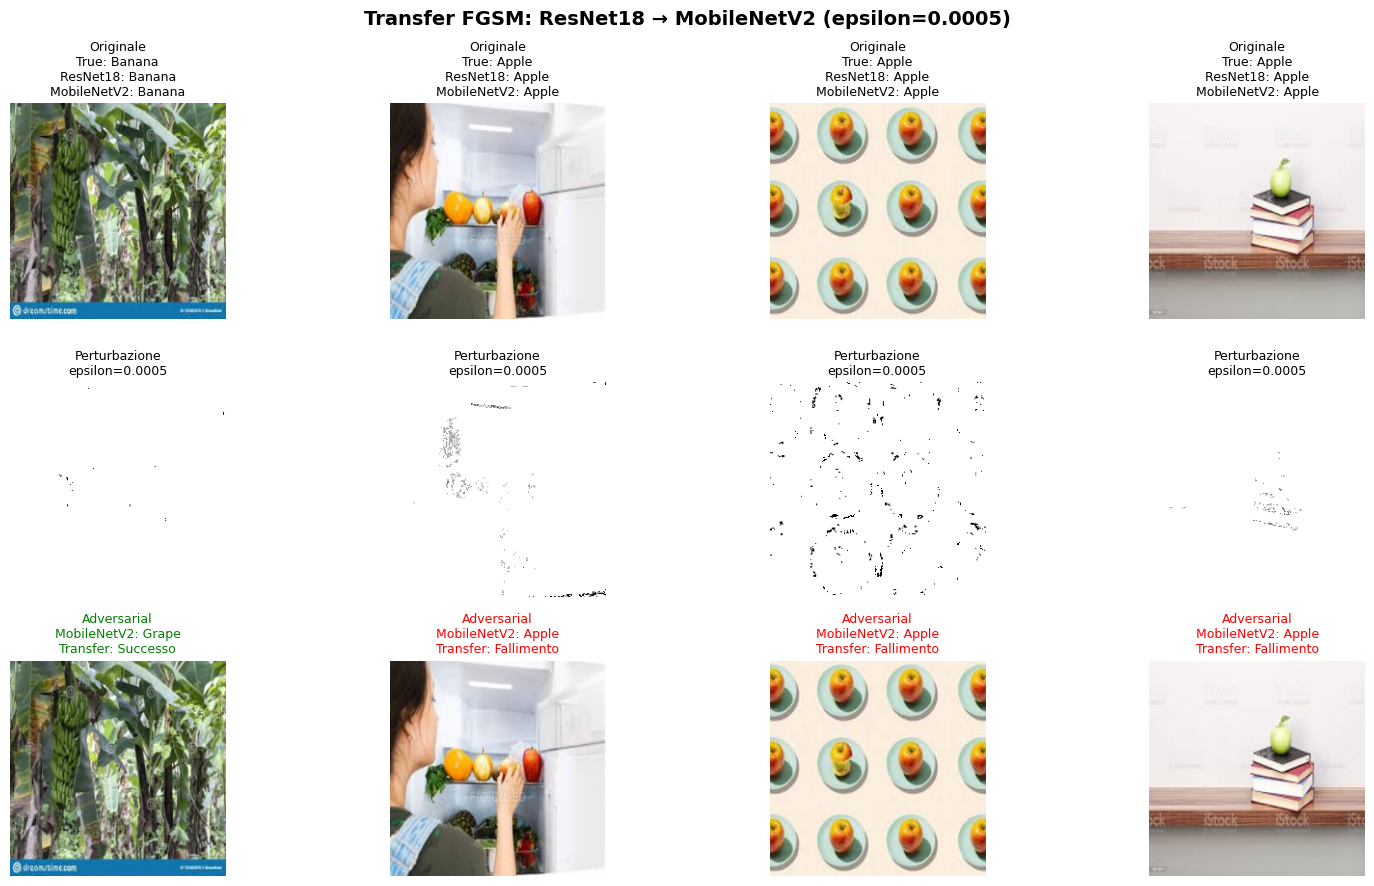

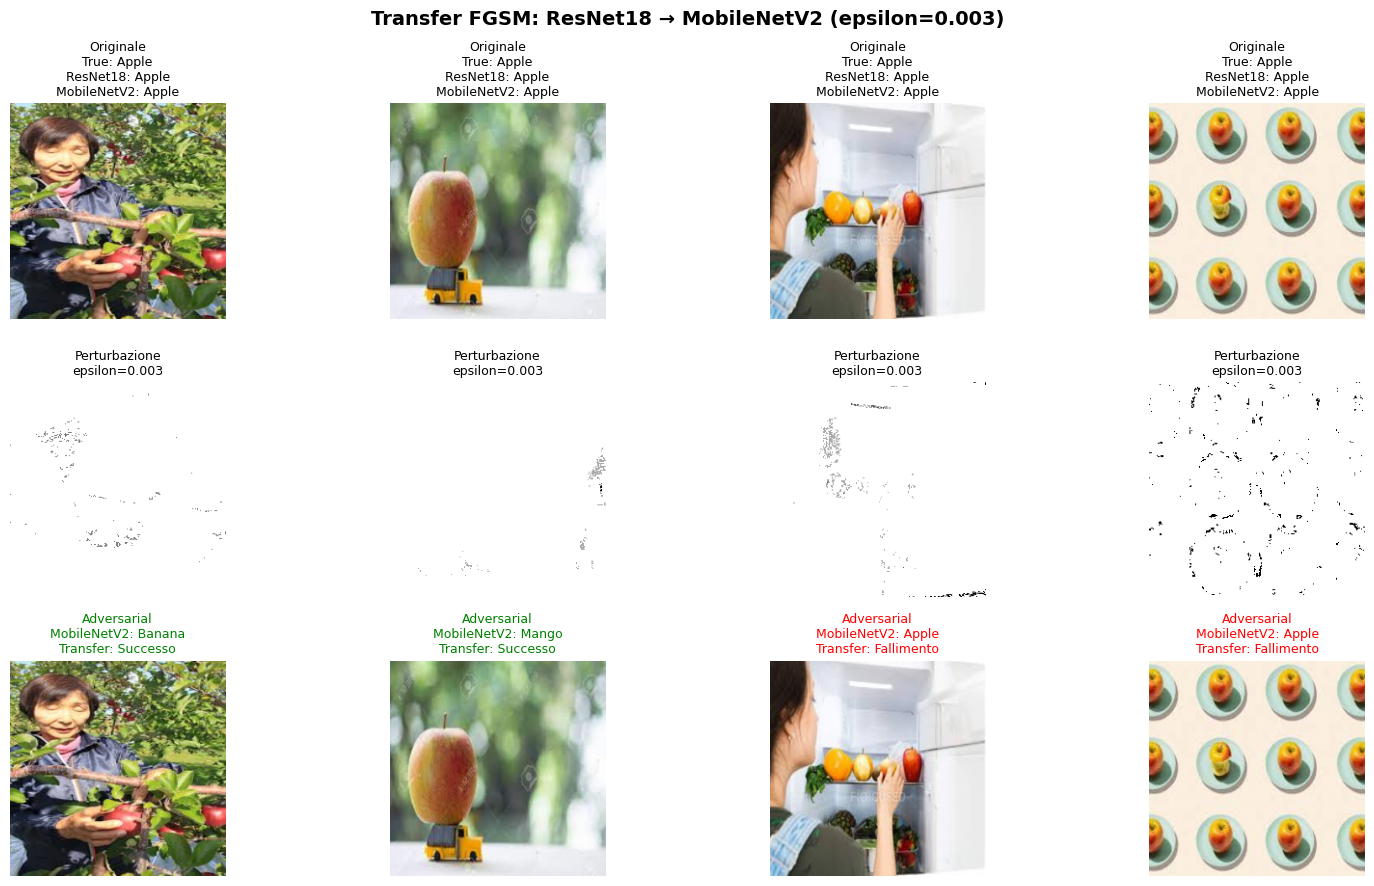

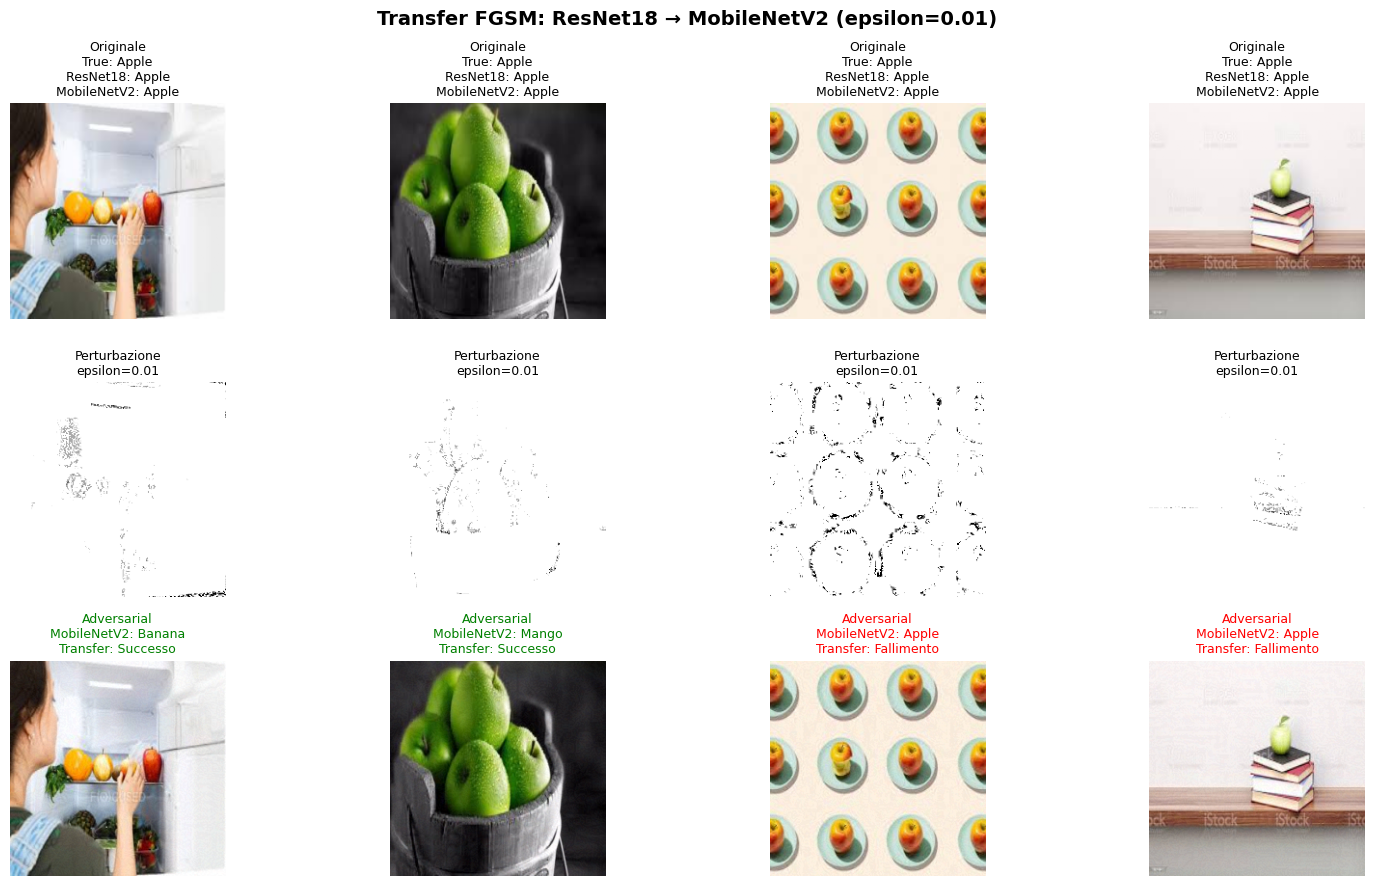

In [ ]:

# transfer FGSM
AMP_FACTOR = 10  # fattore di amplificazione per la perturbazione (Plot 2)

for epsilon in epsilon_to_visualize:

    # seleziona prima i successi e poi i fallimenti
    selected_examples = (
        examples_store[epsilon]['success'][:2]
        + examples_store[epsilon]['failure'][:2]
    )

    # completa fino a 4 esempi, se una categoria ne contiene pochi
    if len(selected_examples) < 4:
        remaining_examples = (
            examples_store[epsilon]['success'][2:]
            + examples_store[epsilon]['failure'][2:]
        )

        selected_examples += remaining_examples[
            :4 - len(selected_examples)
        ]

    n_examples = len(selected_examples)

    # preparazione dati
    data = []
    for example in selected_examples:
        img_original = example['image'][0].numpy()
        img_original = np.transpose(img_original, (1, 2, 0))
        img_original = np.clip(img_original, 0, 1)

        perturbation = example['perturbation'][0].numpy()
        perturbation = np.transpose(perturbation, (1, 2, 0))

        # perturbazione amplificata visivamente: normalizzazione min-max (approccio PyTorch)
        p_min, p_max = perturbation.min(), perturbation.max()
        perturbation_vis = (perturbation - p_min) / (p_max - p_min + 1e-8)

        img_adv = example['adv_image'][0].numpy()
        img_adv = np.transpose(img_adv, (1, 2, 0))
        img_adv = np.clip(img_adv, 0, 1)

        # immagine adv con perturbazione amplificata (AMP_FACTOR x)
        img_adv_amp = np.clip(img_original + perturbation * AMP_FACTOR, 0, 1)

        transfer_success = example['target_adv'] != example['true_label']

        data.append({
            'img_original': img_original,
            'perturbation_vis': perturbation_vis,
            'img_adv': img_adv,
            'img_adv_amp': img_adv_amp,
            'true_label': example['true_label'],
            'source_clean': example['source_clean'],
            'target_clean': example['target_clean'],
            'target_adv': example['target_adv'],
            'transfer_success': transfer_success,
        })

    # plot 1: originale, perturbazione amplificata, adv con perturbazione reale
    fig1, axes1 = plt.subplots(
        3, n_examples, figsize=(4 * n_examples, 9), squeeze=False
    )

    for img_idx, d in enumerate(data):
        result = "Successo" if d['transfer_success'] else "Fallimento"
        color = 'green' if d['transfer_success'] else 'red'

        axes1[0, img_idx].imshow(d['img_original'])
        axes1[0, img_idx].set_title(
            f"Originale\nTrue: {class_names[d['true_label']]}\n"
            f"ResNet18: {class_names[d['source_clean']]}\n"
            f"MobileNetV2: {class_names[d['target_clean']]}",
            fontsize=9
        )
        axes1[0, img_idx].axis('off')

        axes1[1, img_idx].imshow(d['perturbation_vis'])
        axes1[1, img_idx].set_title(
            f"Perturbazione amplificata\nepsilon={epsilon}",
            fontsize=9
        )
        axes1[1, img_idx].axis('off')

        axes1[2, img_idx].imshow(d['img_adv'])
        axes1[2, img_idx].set_title(
            f"Adv (reale)\nMobileNetV2: {class_names[d['target_adv']]}\n"
            f"Transfer: {result}",
            color=color,
            fontsize=9
        )
        axes1[2, img_idx].axis('off')

    plt.suptitle(
        f"Transfer FGSM: ResNet18 → MobileNetV2 (ε={epsilon}) — Adv reale",
        fontsize=14,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(
        results_path / f"Transfer_FGSM_examples_{epsilon}_real.png",
        dpi=120,
        bbox_inches='tight'
    )
    plt.show()

    # plot 2: originale, perturbazione amplificata, adv con perturbazione amplificata
    fig2, axes2 = plt.subplots(
        3, n_examples, figsize=(4 * n_examples, 9), squeeze=False
    )

    for img_idx, d in enumerate(data):
        result = "Successo" if d['transfer_success'] else "Fallimento"
        color = 'green' if d['transfer_success'] else 'red'

        axes2[0, img_idx].imshow(d['img_original'])
        axes2[0, img_idx].set_title(
            f"Originale\nTrue: {class_names[d['true_label']]}\n"
            f"ResNet18: {class_names[d['source_clean']]}\n"
            f"MobileNetV2: {class_names[d['target_clean']]}",
            fontsize=9
        )
        axes2[0, img_idx].axis('off')

        axes2[1, img_idx].imshow(d['perturbation_vis'])
        axes2[1, img_idx].set_title(
            f"Perturbazione amplificata\nepsilon={epsilon}",
            fontsize=9
        )
        axes2[1, img_idx].axis('off')

        axes2[2, img_idx].imshow(d['img_adv_amp'])
        axes2[2, img_idx].set_title(
            f"Adv (amp. {AMP_FACTOR}x)\nMobileNetV2: {class_names[d['target_adv']]}\n"
            f"Transfer: {result}",
            color=color,
            fontsize=9
        )
        axes2[2, img_idx].axis('off')

    plt.suptitle(
        f"Transfer FGSM: ResNet18 → MobileNetV2 (ε={epsilon}) — Adv amplificata ({AMP_FACTOR}×)",
        fontsize=14,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(
        results_path / f"Transfer_FGSM_examples_{epsilon}_amp.png",
        dpi=120,
        bbox_inches='tight'
    )
    plt.show()


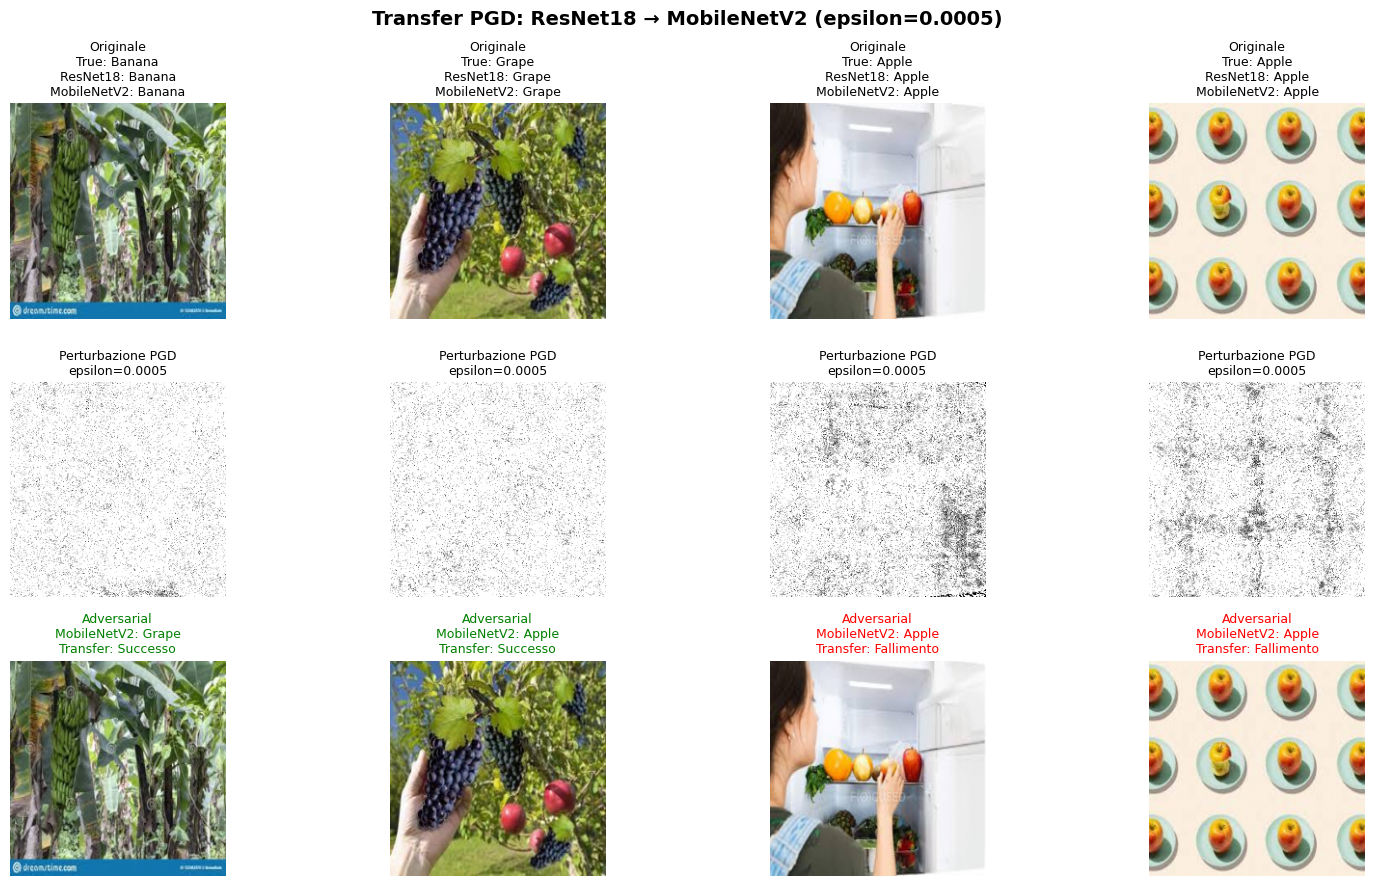

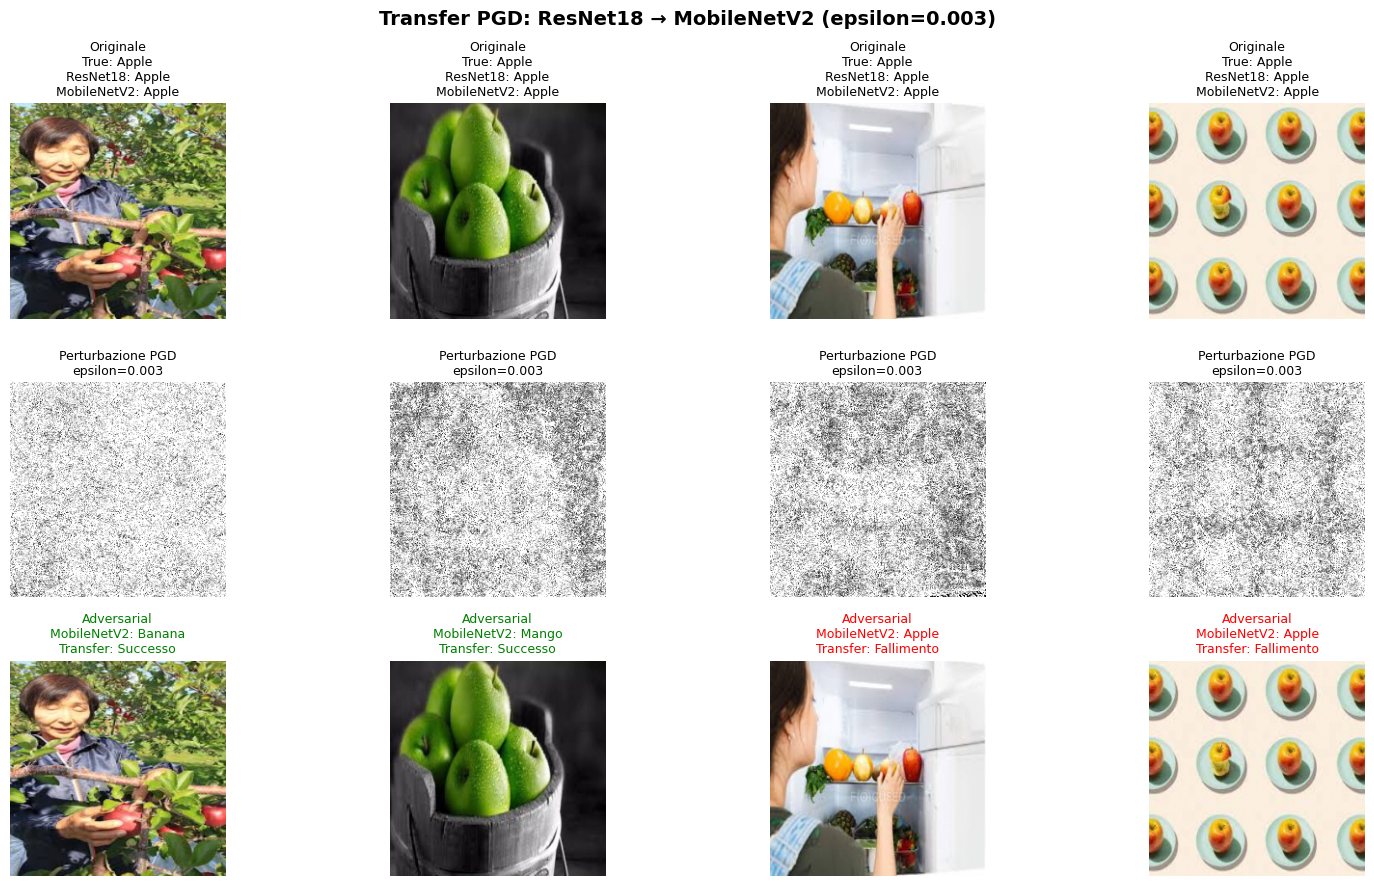

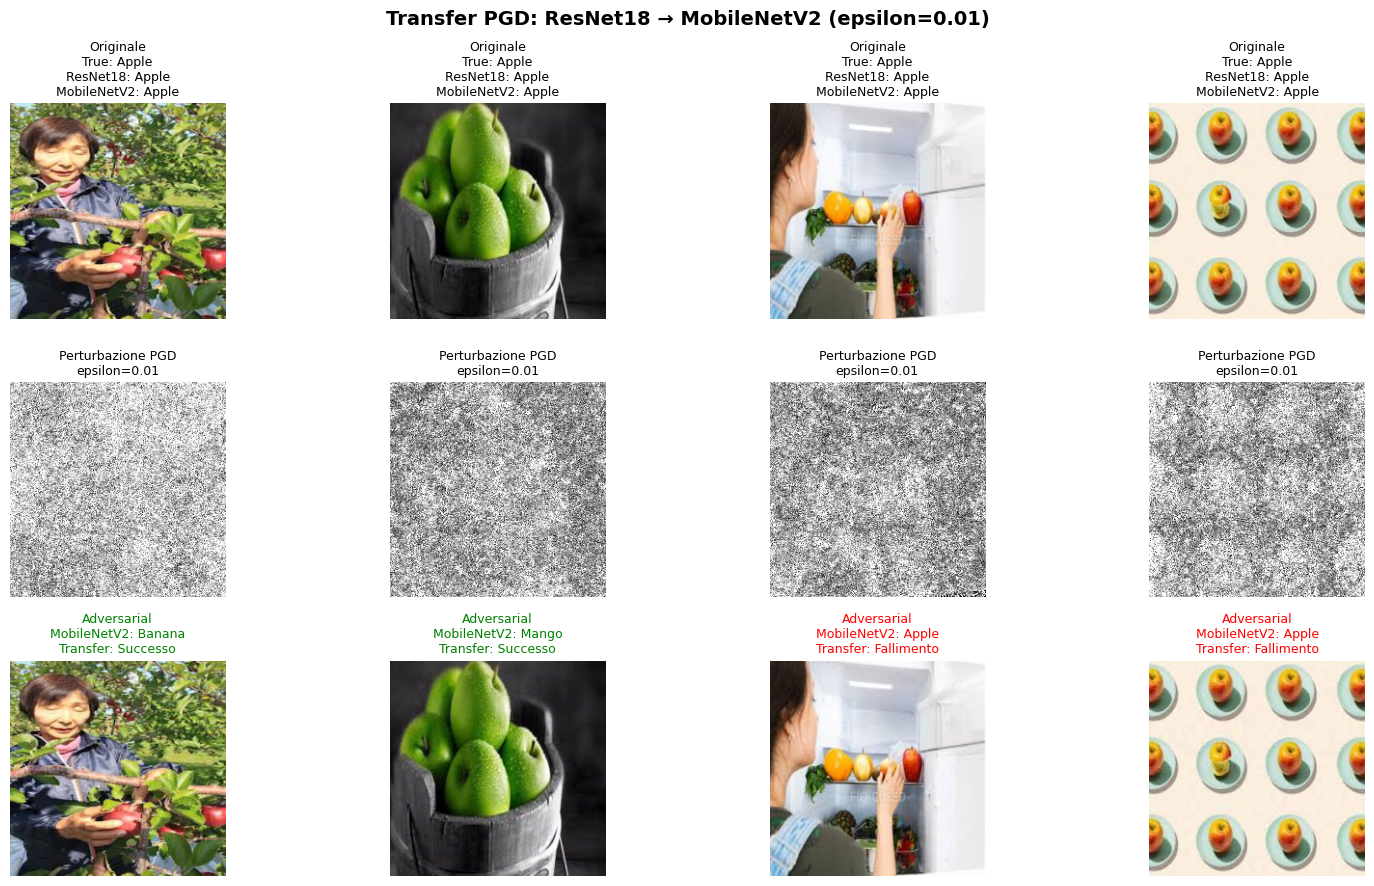

In [ ]:

# transfer PGD
AMP_FACTOR = 10  # fattore di amplificazione per la perturbazione (Plot 2)

for epsilon in epsilon_to_visualize:

    # seleziona due successi e due fallimenti
    selected_examples = (
        pgd_examples_store[epsilon]['success'][:2]
        + pgd_examples_store[epsilon]['failure'][:2]
    )

    # completa fino a 4 esempi se una categoria ne contiene pochi
    if len(selected_examples) < 4:
        remaining_examples = (
            pgd_examples_store[epsilon]['success'][2:]
            + pgd_examples_store[epsilon]['failure'][2:]
        )

        selected_examples += remaining_examples[
            :4 - len(selected_examples)
        ]

    n_examples = len(selected_examples)

    # preparazione dati
    data = []
    for example in selected_examples:
        img_original = example['image'][0].numpy()
        img_original = np.transpose(img_original, (1, 2, 0))
        img_original = np.clip(img_original, 0, 1)

        perturbation = example['perturbation'][0].numpy()
        perturbation = np.transpose(perturbation, (1, 2, 0))

        # perturbazione amplificata visivamente: normalizzazione min-max (approccio PyTorch)
        p_min, p_max = perturbation.min(), perturbation.max()
        perturbation_vis = (perturbation - p_min) / (p_max - p_min + 1e-8)

        img_adv = example['adv_image'][0].numpy()
        img_adv = np.transpose(img_adv, (1, 2, 0))
        img_adv = np.clip(img_adv, 0, 1)

        # immagine adv con perturbazione amplificata (AMP_FACTOR x)
        img_adv_amp = np.clip(img_original + perturbation * AMP_FACTOR, 0, 1)

        transfer_success = example['target_adv'] != example['true_label']

        data.append({
            'img_original': img_original,
            'perturbation_vis': perturbation_vis,
            'img_adv': img_adv,
            'img_adv_amp': img_adv_amp,
            'true_label': example['true_label'],
            'source_clean': example['source_clean'],
            'target_clean': example['target_clean'],
            'target_adv': example['target_adv'],
            'transfer_success': transfer_success,
        })

    # plot 1: originale, perturbazione amplificata, adv con perturbazione reale
    fig1, axes1 = plt.subplots(
        3, n_examples, figsize=(4 * n_examples, 9), squeeze=False
    )

    for img_idx, d in enumerate(data):
        result = "Successo" if d['transfer_success'] else "Fallimento"
        color = 'green' if d['transfer_success'] else 'red'

        axes1[0, img_idx].imshow(d['img_original'])
        axes1[0, img_idx].set_title(
            f"Originale\nTrue: {class_names[d['true_label']]}\n"
            f"ResNet18: {class_names[d['source_clean']]}\n"
            f"MobileNetV2: {class_names[d['target_clean']]}",
            fontsize=9
        )
        axes1[0, img_idx].axis('off')

        axes1[1, img_idx].imshow(d['perturbation_vis'])
        axes1[1, img_idx].set_title(
            f"Perturbazione PGD amplificata\nepsilon={epsilon}",
            fontsize=9
        )
        axes1[1, img_idx].axis('off')

        axes1[2, img_idx].imshow(d['img_adv'])
        axes1[2, img_idx].set_title(
            f"Adv (reale)\nMobileNetV2: {class_names[d['target_adv']]}\n"
            f"Transfer: {result}",
            color=color,
            fontsize=9
        )
        axes1[2, img_idx].axis('off')

    plt.suptitle(
        f"Transfer PGD: ResNet18 → MobileNetV2 (ε={epsilon}) — Adv reale",
        fontsize=14,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(
        results_path / f"Transfer_PGD_examples_{epsilon}_real.png",
        dpi=120,
        bbox_inches='tight'
    )
    plt.show()

    # plot 2: originale, perturbazione amplificata, adv con perturbazione amplificata
    fig2, axes2 = plt.subplots(
        3, n_examples, figsize=(4 * n_examples, 9), squeeze=False
    )

    for img_idx, d in enumerate(data):
        result = "Successo" if d['transfer_success'] else "Fallimento"
        color = 'green' if d['transfer_success'] else 'red'

        axes2[0, img_idx].imshow(d['img_original'])
        axes2[0, img_idx].set_title(
            f"Originale\nTrue: {class_names[d['true_label']]}\n"
            f"ResNet18: {class_names[d['source_clean']]}\n"
            f"MobileNetV2: {class_names[d['target_clean']]}",
            fontsize=9
        )
        axes2[0, img_idx].axis('off')

        axes2[1, img_idx].imshow(d['perturbation_vis'])
        axes2[1, img_idx].set_title(
            f"Perturbazione PGD amplificata\nepsilon={epsilon}",
            fontsize=9
        )
        axes2[1, img_idx].axis('off')

        axes2[2, img_idx].imshow(d['img_adv_amp'])
        axes2[2, img_idx].set_title(
            f"Adv (amp. {AMP_FACTOR}x)\nMobileNetV2: {class_names[d['target_adv']]}\n"
            f"Transfer: {result}",
            color=color,
            fontsize=9
        )
        axes2[2, img_idx].axis('off')

    plt.suptitle(
        f"Transfer PGD: ResNet18 → MobileNetV2 (ε={epsilon}) — Adv amplificata ({AMP_FACTOR}×)",
        fontsize=14,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(
        results_path / f"Transfer_PGD_examples_{epsilon}_amp.png",
        dpi=120,
        bbox_inches='tight'
    )
    plt.show()


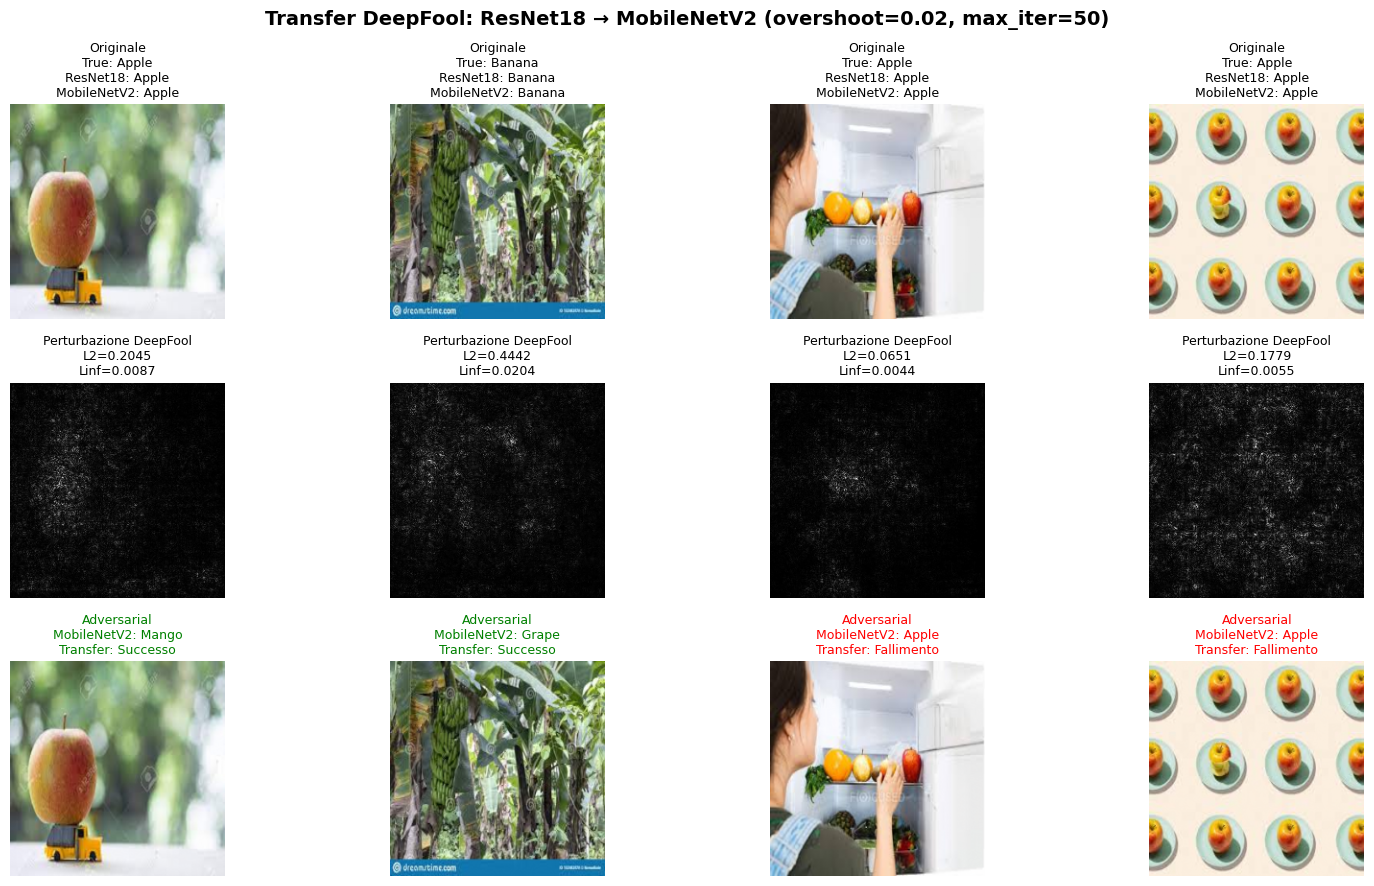

In [ ]:

# transfer DeepFool
AMP_FACTOR = 10  # fattore di amplificazione per la perturbazione (Plot 2)

selected_examples = (
    df_examples_store['success'][:2]
    + df_examples_store['failure'][:2]
)

# completa fino a 4 esempi se una categoria ne contiene pochi
if len(selected_examples) < 4:
    remaining_examples = (
        df_examples_store['success'][2:]
        + df_examples_store['failure'][2:]
    )

    selected_examples += remaining_examples[
        :4 - len(selected_examples)
    ]

n_examples = len(selected_examples)

# preparazione dati
data = []
for example in selected_examples:
    img_original = example['image'][0].numpy()
    img_original = np.transpose(img_original, (1, 2, 0))
    img_original = np.clip(img_original, 0, 1)

    perturbation = example['perturbation'][0].numpy()
    perturbation = np.transpose(perturbation, (1, 2, 0))

    # perturbazione amplificata visivamente: normalizzazione min-max (approccio PyTorch)
    p_min, p_max = perturbation.min(), perturbation.max()
    perturbation_vis = (perturbation - p_min) / (p_max - p_min + 1e-8)

    img_adv = example['adv_image'][0].numpy()
    img_adv = np.transpose(img_adv, (1, 2, 0))
    img_adv = np.clip(img_adv, 0, 1)

    # immagine adv con perturbazione amplificata (AMP_FACTOR x)
    img_adv_amp = np.clip(img_original + perturbation * AMP_FACTOR, 0, 1)

    transfer_success = example['target_adv'] != example['true_label']

    data.append({
        'img_original': img_original,
        'perturbation_vis': perturbation_vis,
        'img_adv': img_adv,
        'img_adv_amp': img_adv_amp,
        'true_label': example['true_label'],
        'source_clean': example['source_clean'],
        'target_clean': example['target_clean'],
        'target_adv': example['target_adv'],
        'l2_norm': example['l2_norm'],
        'linf_norm': example['linf_norm'],
        'transfer_success': transfer_success,
    })

# plot 1: originale | perturbazione amplificata | adv con perturbazione reale
fig1, axes1 = plt.subplots(
    3, n_examples, figsize=(4 * n_examples, 9), squeeze=False
)

for img_idx, d in enumerate(data):
    result = "Successo" if d['transfer_success'] else "Fallimento"
    color = 'green' if d['transfer_success'] else 'red'

    axes1[0, img_idx].imshow(d['img_original'])
    axes1[0, img_idx].set_title(
        f"Originale\nTrue: {class_names[d['true_label']]}\n"
        f"ResNet18: {class_names[d['source_clean']]}\n"
        f"MobileNetV2: {class_names[d['target_clean']]}",
        fontsize=9
    )
    axes1[0, img_idx].axis('off')

    axes1[1, img_idx].imshow(d['perturbation_vis'])
    axes1[1, img_idx].set_title(
        f"Perturbazione DeepFool amplificata\n"
        f"L2={d['l2_norm']:.4f} Linf={d['linf_norm']:.4f}",
        fontsize=9
    )
    axes1[1, img_idx].axis('off')

    axes1[2, img_idx].imshow(d['img_adv'])
    axes1[2, img_idx].set_title(
        f"Adv (reale)\nMobileNetV2: {class_names[d['target_adv']]}\n"
        f"Transfer: {result}",
        color=color,
        fontsize=9
    )
    axes1[2, img_idx].axis('off')

plt.suptitle(
    f"Transfer DeepFool: ResNet18 → MobileNetV2 "
    f"(overshoot={overshoot}, max_iter={max_iter}) — Adv reale",
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    results_path / "Transfer_DeepFool_examples_real.png",
    dpi=120,
    bbox_inches='tight'
)
plt.show()

# plot 2: originale | perturbazione amplificata | adv con perturbazione amplificata
fig2, axes2 = plt.subplots(
    3, n_examples, figsize=(4 * n_examples, 9), squeeze=False
)

for img_idx, d in enumerate(data):
    result = "Successo" if d['transfer_success'] else "Fallimento"
    color = 'green' if d['transfer_success'] else 'red'

    axes2[0, img_idx].imshow(d['img_original'])
    axes2[0, img_idx].set_title(
        f"Originale\nTrue: {class_names[d['true_label']]}\n"
        f"ResNet18: {class_names[d['source_clean']]}\n"
        f"MobileNetV2: {class_names[d['target_clean']]}",
        fontsize=9
    )
    axes2[0, img_idx].axis('off')

    axes2[1, img_idx].imshow(d['perturbation_vis'])
    axes2[1, img_idx].set_title(
        f"Perturbazione DeepFool amplificata\n"
        f"L2={d['l2_norm']:.4f} Linf={d['linf_norm']:.4f}",
        fontsize=9
    )
    axes2[1, img_idx].axis('off')

    axes2[2, img_idx].imshow(d['img_adv_amp'])
    axes2[2, img_idx].set_title(
        f"Adv (amp. {AMP_FACTOR}x)\nMobileNetV2: {class_names[d['target_adv']]}\n"
        f"Transfer: {result}",
        color=color,
        fontsize=9
    )
    axes2[2, img_idx].axis('off')

plt.suptitle(
    f"Transfer DeepFool: ResNet18 → MobileNetV2 "
    f"(overshoot={overshoot}, max_iter={max_iter}) — Adv amplificata ({AMP_FACTOR}×)",
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    results_path / "Transfer_DeepFool_examples_amp.png",
    dpi=120,
    bbox_inches='tight'
)
plt.show()


## 7. Metriche 

In [15]:
fgsm_transfer_df = pd.DataFrame(
    fgsm_transfer_results
)

pgd_transfer_df = pd.DataFrame(
    pgd_transfer_results
)

df_transfer_df = pd.DataFrame(
    df_transfer_results
)

# informazioni comuni
fgsm_transfer_df['setting'] = 'black-box transfer'
fgsm_transfer_df['source_model'] = 'ResNet18'
fgsm_transfer_df['target_model'] = 'MobileNetV2'

pgd_transfer_df['setting'] = 'black-box transfer'
pgd_transfer_df['source_model'] = 'ResNet18'
pgd_transfer_df['target_model'] = 'MobileNetV2'

df_transfer_df['setting'] = 'black-box transfer'
df_transfer_df['source_model'] = 'ResNet18'
df_transfer_df['target_model'] = 'MobileNetV2'

# salvataggio singoli CSV
fgsm_transfer_df.to_csv(
    results_path / "Transfer_FGSM_metrics_summary.csv",
    index=False
)

pgd_transfer_df.to_csv(
    results_path / "Transfer_PGD_metrics_summary.csv",
    index=False
)

df_transfer_df.to_csv(
    results_path / "Transfer_DF_metrics_summary.csv",
    index=False
)

print("Risultati transfer FGSM:")
print(fgsm_transfer_df.to_string(index=False))

print("\nRisultati transfer PGD:")
print(pgd_transfer_df.to_string(index=False))

print("\nRisultati transfer DeepFool:")
print(df_transfer_df.to_string(index=False))

Risultati transfer FGSM:
attack  epsilon  source_clean_accuracy  target_clean_accuracy  source_adv_accuracy  target_adv_accuracy  source_accuracy_drop  target_accuracy_drop  source_asr  transfer_asr  mean_l2  mean_linf   time_s            setting source_model target_model
  FGSM   0.0005               0.911824               0.930862             0.809619             0.925852              0.102204              0.005010    0.112088      0.001135 0.189483     0.0005 1.399879 black-box transfer     ResNet18  MobileNetV2
  FGSM   0.0010               0.911824               0.930862             0.689379             0.922846              0.222445              0.008016    0.243956      0.003405 0.378955     0.0010 0.934256 black-box transfer     ResNet18  MobileNetV2
  FGSM   0.0030               0.911824               0.930862             0.359719             0.906814              0.552104              0.024048    0.605495      0.015891 1.136878     0.0030 1.366067 black-box transfer     ResNe

## 8. Riepilogo


Riepilogo Transfer Attacks
  attack            setting source_model target_model epsilon    alpha  num_steps  overshoot  max_iter  source_clean_accuracy  target_clean_accuracy  source_adv_accuracy  target_adv_accuracy  source_accuracy_drop  target_accuracy_drop  source_asr  transfer_asr  mean_l2  mean_linf    time_s
    FGSM black-box transfer     ResNet18  MobileNetV2  0.0005      NaN        NaN        NaN       NaN               0.911824               0.930862             0.809619             0.925852              0.102204              0.005010    0.112088      0.001135 0.189483   0.000500  1.399879
    FGSM black-box transfer     ResNet18  MobileNetV2   0.001      NaN        NaN        NaN       NaN               0.911824               0.930862             0.689379             0.922846              0.222445              0.008016    0.243956      0.003405 0.378955   0.001000  0.934256
    FGSM black-box transfer     ResNet18  MobileNetV2   0.003      NaN        NaN        NaN       

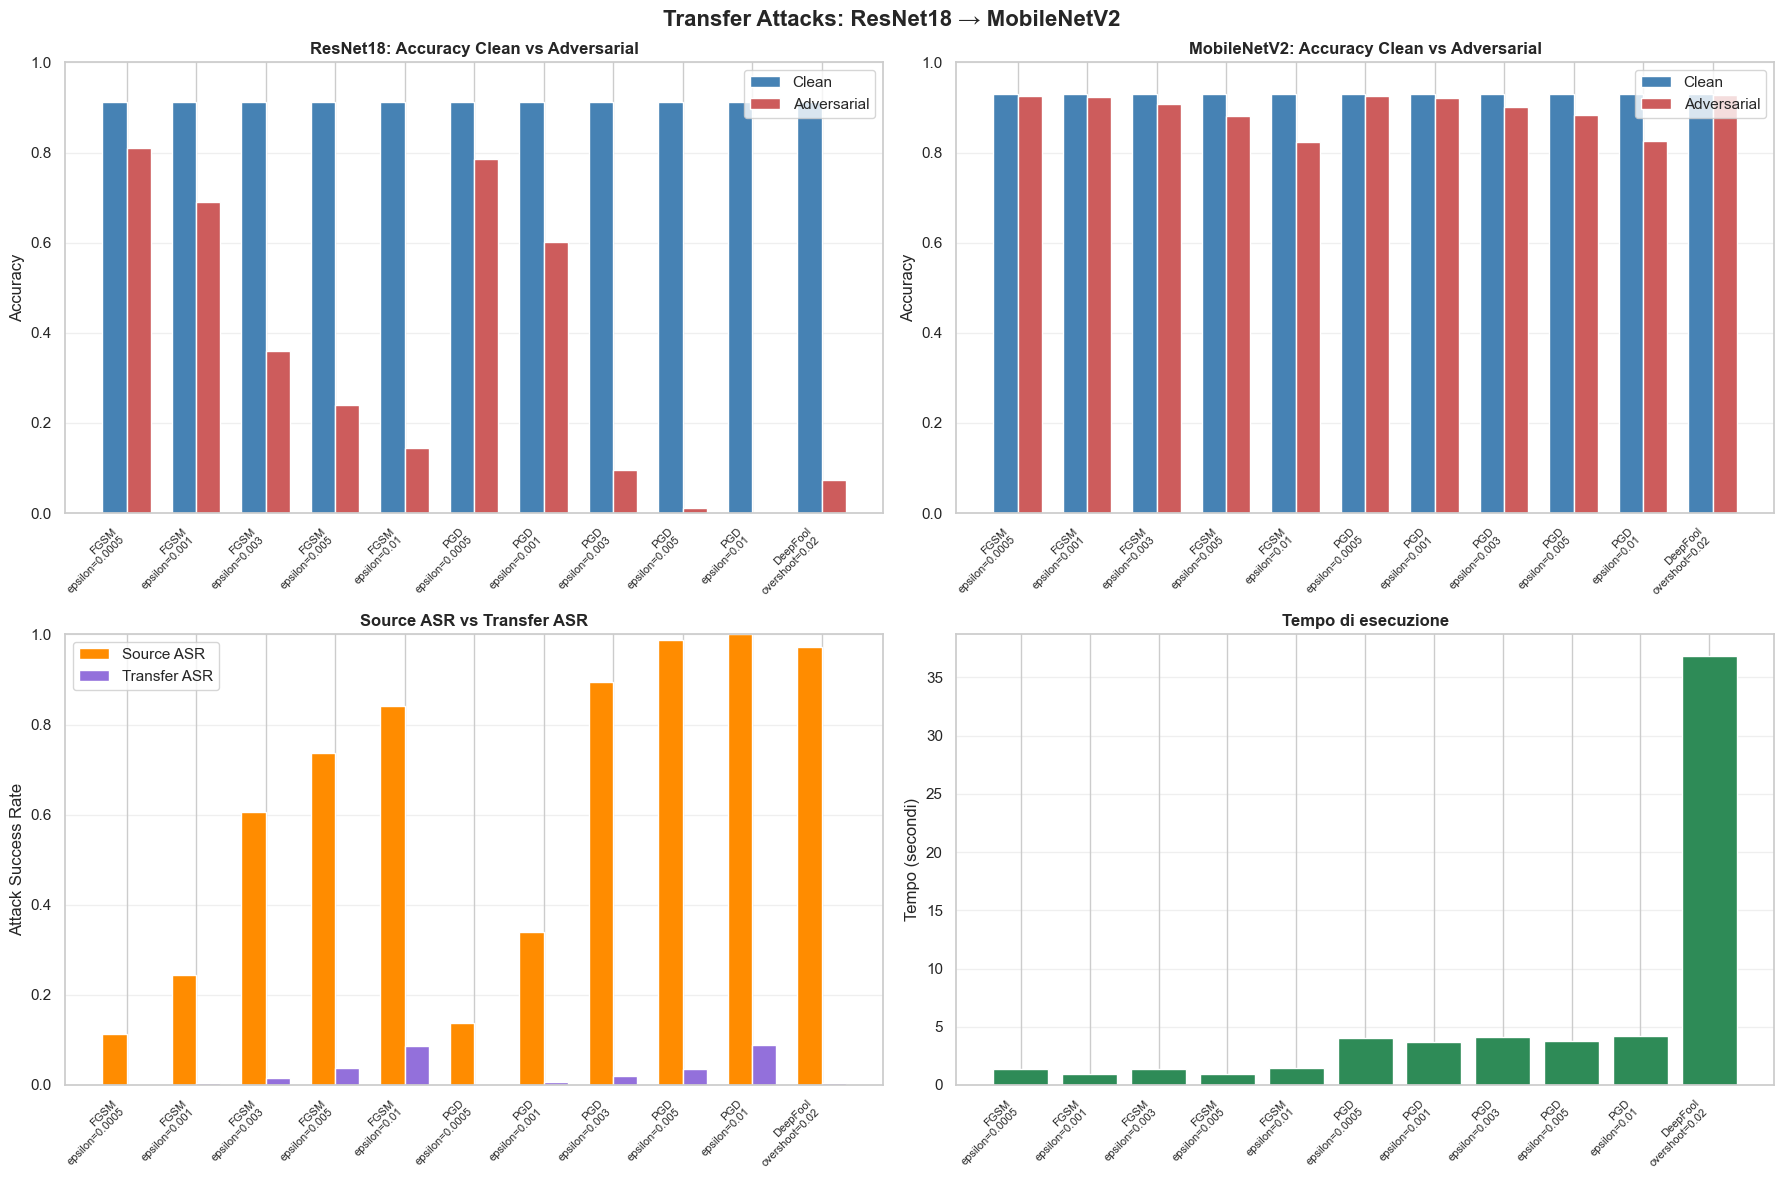


Grafico salvato in: ../results/Transfer_metrics_summary.png


In [16]:
transfer_results_df = pd.concat(
    [
        fgsm_transfer_df,
        pgd_transfer_df,
        df_transfer_df
    ],
    ignore_index=True
)

columns_order = [
    'attack',
    'setting',
    'source_model',
    'target_model',
    'epsilon',
    'alpha',
    'num_steps',
    'overshoot',
    'max_iter',
    'source_clean_accuracy',
    'target_clean_accuracy',
    'source_adv_accuracy',
    'target_adv_accuracy',
    'source_accuracy_drop',
    'target_accuracy_drop',
    'source_asr',
    'transfer_asr',
    'mean_l2',
    'mean_linf',
    'time_s'
]

# alcune colonne non esistono per tutti gli attacchi
for column in columns_order:
    if column not in transfer_results_df.columns:
        transfer_results_df[column] = np.nan

transfer_results_df = transfer_results_df[
    columns_order
]

transfer_results_df.to_csv(
    results_path / "Transfer_metrics_summary.csv",
    index=False
)

print("\nRiepilogo Transfer Attacks")
print(
    transfer_results_df.to_string(
        index=False
    )
)

print("\nTabella salvata in:")
print(results_path / "Transfer_metrics_summary.csv")

# plot delle metriche

plot_labels = []

for _, row in transfer_results_df.iterrows():
    if row['attack'] == 'DeepFool':
        label = (
            f"DeepFool\n"
            f"overshoot={row['overshoot']}"
        )
    else:
        label = (
            f"{row['attack']}\n"
            f"epsilon={row['epsilon']}"
        )

    plot_labels.append(label)


x = np.arange(len(transfer_results_df))
width = 0.35

sns.set(style='whitegrid')

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12)
)

# accuracy del modello sorgente
axes[0, 0].bar(
    x - width / 2,
    transfer_results_df['source_clean_accuracy'],
    width,
    label='Clean',
    color='steelblue'
)

axes[0, 0].bar(
    x + width / 2,
    transfer_results_df['source_adv_accuracy'],
    width,
    label='Adversarial',
    color='indianred'
)

axes[0, 0].set_title(
    'ResNet18: Accuracy Clean vs Adversarial',
    fontweight='bold'
)

axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend()


# accuracy del modello target
axes[0, 1].bar(
    x - width / 2,
    transfer_results_df['target_clean_accuracy'],
    width,
    label='Clean',
    color='steelblue'
)

axes[0, 1].bar(
    x + width / 2,
    transfer_results_df['target_adv_accuracy'],
    width,
    label='Adversarial',
    color='indianred'
)

axes[0, 1].set_title(
    'MobileNetV2: Accuracy Clean vs Adversarial',
    fontweight='bold'
)

axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()


# Source ASR vs Transfer ASR
axes[1, 0].bar(
    x - width / 2,
    transfer_results_df['source_asr'],
    width,
    label='Source ASR',
    color='darkorange'
)

axes[1, 0].bar(
    x + width / 2,
    transfer_results_df['transfer_asr'],
    width,
    label='Transfer ASR',
    color='mediumpurple'
)

axes[1, 0].set_title(
    'Source ASR vs Transfer ASR',
    fontweight='bold'
)

axes[1, 0].set_ylabel('Attack Success Rate')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()


# tempo di esecuzione
axes[1, 1].bar(
    x,
    transfer_results_df['time_s'],
    color='seagreen'
)

axes[1, 1].set_title(
    'Tempo di esecuzione',
    fontweight='bold'
)

axes[1, 1].set_ylabel('Tempo (secondi)')


# etichette per tutti i grafici
for ax in axes.flatten():
    ax.set_xticks(x)

    ax.set_xticklabels(
        plot_labels,
        rotation=45,
        ha='right',
        fontsize=8
    )

    ax.grid(
        True,
        alpha=0.3,
        axis='y'
    )


plt.suptitle(
    'Transfer Attacks: ResNet18 → MobileNetV2',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    results_path / "Transfer_metrics_summary.png",
    dpi=120,
    bbox_inches='tight'
)

plt.show()

print(
    "\nGrafico salvato in:",
    results_path / "Transfer_metrics_summary.png"
)